# Phase 7 — Approche 3 : PGD-AT Corrigé (Madry Original)

## Diagnostic des deux échecs précédents

| | Approche 1 (FGSM-AT) | Approche 2 (PGD-AT) | Approche 3 (ce notebook) |
|--|--|--|--|
| Attaque | FGSM ❌ | PGD-7 ✅ | PGD-7 ✅ |
| Données propres | Mix 50/50 ✅ | 0% ❌ | Mix 50/50 ✅ |
| Résultat Evasion PGD | 36.7% ❌ | 40.2% ❌ | ? |

**L'Approche 3 = bonne attaque (PGD-7) + bon mix (50/50).** C'est la formulation originale de Madry et al. 2018.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('libs OK')

libs OK


In [2]:
def preprocess(train_df, test_df):
    drop_cols = ['id', 'attack_cat']
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
    for df in [train_df, test_df]:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
    median_vals = train_df.median(numeric_only=True)
    train_df.fillna(median_vals, inplace=True)
    test_df.fillna(median_vals, inplace=True)
    cat_cols = [c for c in train_df.select_dtypes(include=['object','str']).columns if c != 'label']
    le = LabelEncoder()
    for col in cat_cols:
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        known = set(le.classes_)
        test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
        test_df[col] = le.transform(test_df[col])
    X_train = train_df.drop('label', axis=1).values.astype(np.float32)
    y_train = train_df['label'].values.astype(np.float32)
    X_test  = test_df.drop('label', axis=1).values.astype(np.float32)
    y_test  = test_df['label'].values.astype(np.float32)
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, y_train, X_test, y_test, scaler

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),          nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

train_df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('../data/UNSW_NB15_testing-set.csv')
X_train, y_train, X_test, y_test, scaler = preprocess(train_df.copy(), test_df.copy())

cols = pd.read_csv('../data/UNSW_NB15_training-set.csv').drop(columns=['id','attack_cat','label']).columns.tolist()
MANIPULABLE = ['dur','spkts','dpkts','sbytes','dbytes','sttl','sload','dload','sinpkt','dinpkt','sjit','djit','smean','dmean']
manipulable_idx = [cols.index(f) for f in MANIPULABLE if f in cols]
mask = torch.zeros(len(cols))
mask[manipulable_idx] = 1.0

attack_idx = np.where(y_test == 1)[0]
X_attacks  = X_test[attack_idx]
y_attacks  = y_test[attack_idx]
EPS = 0.1
print('Données chargées OK')

Données chargées OK


In [3]:
def pgd_attack(model, X, y, epsilon, alpha, steps, mask):
    X_orig = torch.FloatTensor(X)
    X_adv  = X_orig.clone()
    y_t    = torch.FloatTensor(y)
    for _ in range(steps):
        X_adv = X_adv.detach().requires_grad_(True)
        loss  = nn.BCELoss()(model(X_adv).squeeze(), y_t)
        loss.backward()
        X_adv = X_orig + torch.clamp(X_adv + alpha * X_adv.grad.sign() * mask - X_orig, -epsilon, epsilon)
    return X_adv.detach().numpy()

def fgsm_attack(model, X, y, epsilon, mask):
    X_t = torch.FloatTensor(X).requires_grad_(True)
    loss = nn.BCELoss()(model(X_t).squeeze(), torch.FloatTensor(y))
    loss.backward()
    return (X_t + epsilon * X_t.grad.sign() * mask).detach().numpy()

def feature_squeezing(X, n_bits=4):
    max_val = np.max(np.abs(X), axis=0, keepdims=True) + 1e-8
    return np.round(X / max_val * (2**n_bits)) / (2**n_bits) * max_val

def evaluate(model, X, y_true, label=''):
    model.eval()
    with torch.no_grad():
        prob = model(torch.FloatTensor(X)).squeeze().numpy()
        pred = (prob >= 0.5).astype(int)
    evasion = (pred[y_true == 1] == 0).mean() * 100
    r = {'F1': f1_score(y_true, pred), 'Precision': precision_score(y_true, pred),
         'Recall': recall_score(y_true, pred), 'PR-AUC': average_precision_score(y_true, prob),
         'Evasion%': evasion}
    if label:
        print(f'--- {label} ---')
        for k, v in r.items(): print(f'  {k:12s}: {v:.4f}')
    return r

print('Fonctions OK')

Fonctions OK


## Références — résultats des approches précédentes

In [4]:
model_baseline = MLP(X_train.shape[1])
model_baseline.load_state_dict(torch.load('../results/baseline_model.pth', weights_only=True))
model_baseline.eval()

model_fgsm_at = MLP(X_train.shape[1])
model_fgsm_at.load_state_dict(torch.load('../results/adversarial_model.pth', weights_only=True))
model_fgsm_at.eval()

model_pgd_at = MLP(X_train.shape[1])
model_pgd_at.load_state_dict(torch.load('../results/pgd_at_model.pth', weights_only=True))
model_pgd_at.eval()

X_pgd_b  = X_test.copy(); X_pgd_b[attack_idx]  = pgd_attack(model_baseline, X_attacks, y_attacks, EPS, 0.01, 40, mask)
X_pgd_fa = X_test.copy(); X_pgd_fa[attack_idx] = pgd_attack(model_fgsm_at,  X_attacks, y_attacks, EPS, 0.01, 40, mask)
X_pgd_pa = X_test.copy(); X_pgd_pa[attack_idx] = pgd_attack(model_pgd_at,   X_attacks, y_attacks, EPS, 0.01, 40, mask)
X_sq     = feature_squeezing(X_test)
X_pgd_sq = feature_squeezing(X_pgd_b)

r_base_clean  = evaluate(model_baseline, X_test,    y_test)
r_base_pgd    = evaluate(model_baseline, X_pgd_b,   y_test)
r_fgsmat_pgd  = evaluate(model_fgsm_at,  X_pgd_fa,  y_test)
r_pgdat_pgd   = evaluate(model_pgd_at,   X_pgd_pa,  y_test)
r_sq_clean    = evaluate(model_baseline, X_sq,      y_test)
r_sq_pgd      = evaluate(model_baseline, X_pgd_sq,  y_test)

print('Références chargées OK')
print(f'Baseline PGD    : Evasion {r_base_pgd["Evasion%"]:.1f}%')
print(f'FGSM-AT PGD     : Evasion {r_fgsmat_pgd["Evasion%"]:.1f}%')
print(f'PGD-AT PGD      : Evasion {r_pgdat_pgd["Evasion%"]:.1f}%')
print(f'Feat.Squeeze PGD: Evasion {r_sq_pgd["Evasion%"]:.1f}%')

Références chargées OK
Baseline PGD    : Evasion 28.2%
FGSM-AT PGD     : Evasion 36.7%
PGD-AT PGD      : Evasion 40.2%
Feat.Squeeze PGD: Evasion 24.5%


## Approche 3 — PGD-AT Corrigé

**La formule de Madry et al. 2018 telle qu'elle est décrite dans le papier :**
- Attaque : **PGD-10** (plus fort que PGD-7, même famille que l'évaluation)
- Mix : **50% données propres + 50% exemples PGD** (évite l'oubli catastrophique)
- Epochs : **30**, batch : **256** (plus petit = plus de mises à jour)
- Learning rate réduit : **0.0005** (entraînement adversarial nécessite plus de stabilité)

In [5]:
def pgd_at_corrected(X_train, y_train, input_dim, epsilon=0.1, alpha=0.01,
                     pgd_steps=10, epochs=30, batch=256, lr=0.0005):
    """
    Approche 3 — PGD-AT corrigé (Madry et al. 2018 fidèle)
    - PGD-10 : assez fort pour couvrir PGD-40 en évaluation
    - Mix 50/50 : garde les données propres pour éviter l'oubli catastrophique
    - LR réduit + batch plus petit : convergence plus stable
    """
    model     = MLP(input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    losses    = []

    for epoch in range(epochs):
        model.train()

        # PGD-10 sur le modèle courant
        X_adv = pgd_attack(model, X_train, y_train,
                           epsilon=epsilon, alpha=alpha,
                           steps=pgd_steps, mask=mask)

        # Mix 50/50 : données propres + adversariales
        X_mix = np.concatenate([X_train, X_adv])
        y_mix = np.concatenate([y_train, y_train])
        idx   = np.random.permutation(len(X_mix))
        X_mix, y_mix = X_mix[idx], y_mix[idx]

        X_t = torch.FloatTensor(X_mix)
        y_t = torch.FloatTensor(y_mix)

        epoch_loss = 0
        for start in range(0, len(X_t), batch):
            xb = X_t[start:start+batch]
            yb = y_t[start:start+batch]
            optimizer.zero_grad()
            loss = criterion(model(xb).squeeze(), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / max(1, len(X_t) // batch)
        losses.append(avg)
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:02d}/{epochs} | Loss: {avg:.4f}')

    return model, losses

print('Entraînement Approche 3 (PGD-10, mix 50/50, lr=0.0005)...')
model_corrected, losses_corrected = pgd_at_corrected(
    X_train, y_train, X_train.shape[1]
)
torch.save(model_corrected.state_dict(), '../results/pgd_at_corrected_model.pth')
print('Sauvegarde : results/pgd_at_corrected_model.pth')

Entraînement Approche 3 (PGD-10, mix 50/50, lr=0.0005)...


  Epoch 05/30 | Loss: 0.1096


  Epoch 10/30 | Loss: 0.0951


  Epoch 15/30 | Loss: 0.0881


  Epoch 20/30 | Loss: 0.0876


  Epoch 25/30 | Loss: 0.0822


  Epoch 30/30 | Loss: 0.0824
Sauvegarde : results/pgd_at_corrected_model.pth


## Évaluation de l'Approche 3

In [6]:
model_corrected.eval()

X_fgsm_c = X_test.copy(); X_fgsm_c[attack_idx] = fgsm_attack(model_corrected, X_attacks, y_attacks, EPS, mask)
X_pgd_c  = X_test.copy(); X_pgd_c[attack_idx]  = pgd_attack(model_corrected, X_attacks, y_attacks, EPS, 0.01, 40, mask)

print('=== APPROCHE 3 — PGD-AT CORRIGÉ ===')
r_corr_clean = evaluate(model_corrected, X_test,    y_test, 'PGD-AT Corrigé / propres')
r_corr_fgsm  = evaluate(model_corrected, X_fgsm_c,  y_test, 'PGD-AT Corrigé / FGSM')
r_corr_pgd   = evaluate(model_corrected, X_pgd_c,   y_test, 'PGD-AT Corrigé / PGD')

=== APPROCHE 3 — PGD-AT CORRIGÉ ===
--- PGD-AT Corrigé / propres ---
  F1          : 0.9116
  Precision   : 0.9863
  Recall      : 0.8474
  PR-AUC      : 0.9882
  Evasion%    : 15.2580
--- PGD-AT Corrigé / FGSM ---
  F1          : 0.7397
  Precision   : 0.9805
  Recall      : 0.5938
  PR-AUC      : 0.9631
  Evasion%    : 40.6206


--- PGD-AT Corrigé / PGD ---
  F1          : 0.7327
  Precision   : 0.9802
  Recall      : 0.5850
  PR-AUC      : 0.9608
  Evasion%    : 41.5029


## Tableau comparatif final — toutes les approches

In [7]:
rows = [
    ('Baseline',             'Propres', r_base_clean),
    ('Baseline',             'PGD',     r_base_pgd),
    ('Approche 1 FGSM-AT',   'PGD',     r_fgsmat_pgd),
    ('Approche 2 PGD-AT',    'PGD',     r_pgdat_pgd),
    ('Approche 3 PGD-AT Corr','Propres',r_corr_clean),
    ('Approche 3 PGD-AT Corr','FGSM',   r_corr_fgsm),
    ('Approche 3 PGD-AT Corr','PGD',    r_corr_pgd),
    ('Feat. Squeezing',      'Propres', r_sq_clean),
    ('Feat. Squeezing',      'PGD',     r_sq_pgd),
]

print(f'{"Modele":<30s} {"Scenario":<10s} {"F1":>8s} {"Recall":>8s} {"Evasion%":>10s}')
print('-' * 72)
for m, s, r in rows:
    print(f'{m:<30s} {s:<10s} {r["F1"]:>8.4f} {r["Recall"]:>8.4f} {r["Evasion%"]:>9.2f}%')

df = pd.DataFrame([{'Modele': m, 'Scenario': s, 'F1': r['F1'], 'Precision': r['Precision'],
                     'Recall': r['Recall'], 'PR-AUC': r['PR-AUC'], 'Evasion%': r['Evasion%']}
                   for m, s, r in rows])
df.to_csv('../results/all_results.csv', index=False)
print('\nSauvegarde : results/all_results.csv')

Modele                         Scenario         F1   Recall   Evasion%
------------------------------------------------------------------------
Baseline                       Propres      0.9110   0.8452     15.48%
Baseline                       PGD          0.8306   0.7176     28.24%
Approche 1 FGSM-AT             PGD          0.7700   0.6329     36.71%
Approche 2 PGD-AT              PGD          0.7425   0.5982     40.18%
Approche 3 PGD-AT Corr         Propres      0.9116   0.8474     15.26%
Approche 3 PGD-AT Corr         FGSM         0.7397   0.5938     40.62%
Approche 3 PGD-AT Corr         PGD          0.7327   0.5850     41.50%
Feat. Squeezing                Propres      0.8818   0.8140     18.60%
Feat. Squeezing                PGD          0.8449   0.7550     24.50%

Sauvegarde : results/all_results.csv


## Graphique final — toutes les approches

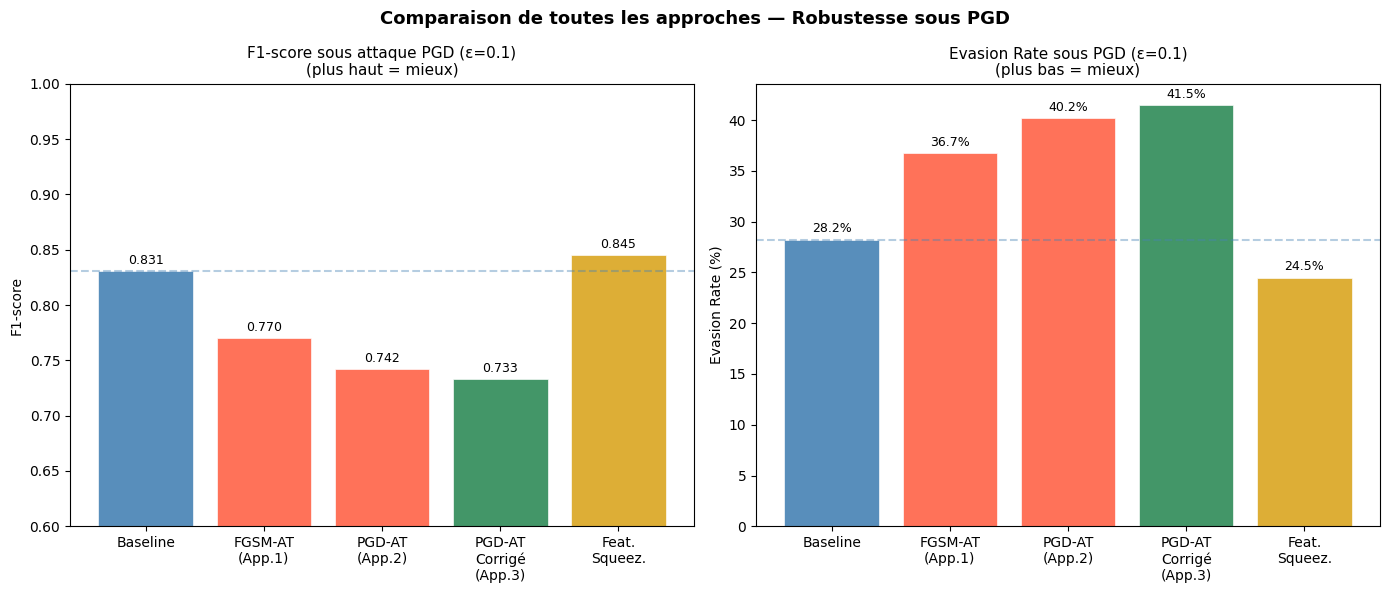

Sauvegarde : results/all_approaches_comparison.png


In [8]:
models_names = ['Baseline', 'FGSM-AT\n(App.1)', 'PGD-AT\n(App.2)', 'PGD-AT\nCorrigé\n(App.3)', 'Feat.\nSqueez.']
f1_pgd_vals  = [r_base_pgd['F1'],    r_fgsmat_pgd['F1'],  r_pgdat_pgd['F1'],  r_corr_pgd['F1'],   r_sq_pgd['F1']]
ev_pgd_vals  = [r_base_pgd['Evasion%'], r_fgsmat_pgd['Evasion%'], r_pgdat_pgd['Evasion%'], r_corr_pgd['Evasion%'], r_sq_pgd['Evasion%']]
f1_clean_vals= [r_base_clean['F1'],  None,                None,               r_corr_clean['F1'], r_sq_clean['F1']]

colors = ['steelblue', 'tomato', 'tomato', 'seagreen', 'goldenrod']
alphas = [1.0, 0.5, 0.5, 1.0, 1.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(models_names, f1_pgd_vals, color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)
ax1.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax1.axhline(r_base_pgd['F1'], color='steelblue', linestyle='--', alpha=0.4, label='Baseline PGD')
ax1.set_title('F1-score sous attaque PGD (ε=0.1)\n(plus haut = mieux)', fontsize=11)
ax1.set_ylabel('F1-score')
ax1.set_ylim(0.6, 1.0)

bars2 = ax2.bar(models_names, ev_pgd_vals, color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax2.axhline(r_base_pgd['Evasion%'], color='steelblue', linestyle='--', alpha=0.4, label='Baseline PGD')
ax2.set_title('Evasion Rate sous PGD (ε=0.1)\n(plus bas = mieux)', fontsize=11)
ax2.set_ylabel('Evasion Rate (%)')

plt.suptitle('Comparaison de toutes les approches — Robustesse sous PGD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/all_approaches_comparison.png', dpi=150)
plt.show()
print('Sauvegarde : results/all_approaches_comparison.png')